In [1]:
from collections import defaultdict
from scipy import stats
from scipy.stats import erlang, expon, norm 
from itertools import product, combinations
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import time # benchmarking

# User Defined Modules
from infection_propagation import Graph
from infection_propagation import Figures

from tree_source_localization import EdgeDistribution


import importlib
importlib.reload(Graph)
importlib.reload(Figures)

<module 'infection_propagation.Figures' from '/home/danny/cuboulder/IMPORTANT_SIDE_STUFF_LIKE_JOB/research/infection_propagation/src/infection_propagation/Figures.py'>

In [10]:
V = { "distribution": "E", "parameters": { "lambda" : 1.0 } }
rv = EdgeDistribution.EdgeDistribution(V["distribution"], V["parameters"])
rv.sample()
rv.delay

0.871795652454357

In [11]:
class abstractRV(stats.rv_continuous):
    def __init__(self, xtol=1e-14, seed=None, cdf=lambda x: 2):
        super().__init__(a=0, xtol=xtol, seed=seed)
        self._custom_cdf = cdf

    def _cdf(self, x):
        self._custom_cdf(x)

In [12]:
p = abstractRV(cdf= lambda x: 1-np.exp(-x**2))
# p.rvs(size=1000)

#### Extracting Global Time From Matrix?

# Tasks:

- [x] Make infect time histogram
- [x] Make path histogram
- [x] Test Random Graphs, with n nodes, 1 is src and n is end, check if graph is connected
    - [x] ER-model, parameterize n and p, 
    - [x] if connected run 1000+ simulations
        - [x] overall connected, we don't wnat to run simulations on small components
        - [x] graph is connect if laplacian rank is n-1, manually create 1x1 adjacency and degree matricies?, more efficient than bfs?
- [x] may need to bench bfs compared to laplacian or just checking connectedness at graph initalization
    - Generally weary of having to create 2 new data structures just to calculate one thig
- [x] compact adjacency matrix (don't print literal name of RV)
- [x] ER part 2 
    - [x] Singleton nodes are relevant in connectivity
    - [x] allow for predefined dict of edge weights
    - [x] verify erdos-reiygni
    - [x] have trials with both fixed Gnp and 
    - [x] have trials with resimulated Gnp
        - [x] fix cycle edge case
- [ ] Pythonize code
    - [ ] organize code layout
    - [ ] kwarg utilization
    - [ ] OOP
- [ ] Input data like Devlin's
    - [ ] format down, just need to support other distributions
    - [x] copy `EdgeDistribution.py` from Devlin's repo?
- [ ] Distribution method like Devlin's 
    - [x] may use Devlin's method of separate class resolver
    - [ ] Generalize Edge Distribtion assignment (custom CDFS)
        - [ ] can extend Devlin's edge resolver class to allow for custom cdfs via scipy.stats.rv
- [ ] Make figures look neater for higher path_counts
    - [x] fix plot scaling
    - [x] maybe segregate plots later? Better for make figures in presentations
    - [ ] maybe at restrictions to only plot above a threshold
- [ ] Analyze memory efficiency of code
    - [ ] How efficient is laplacian check?
    - [ ] Why is high node count so difficult on ER? Computer issue or code issue?
        - [ ] Does inefficiency depend being a dense vs sparse graph?
            - [ ] Edges present vs total edges
            - [ ] average degrees
            - [ ] shortest path distances efficiently (kneedle's algorithm)
            - [ ] A* heuristic based on chernoff bounds
    - [ ] If we satisfy the connectivity threshold should I skip checking connectivity
    - [ ] Meta-data structures? (ie to track connectivity)
    - [x] High node counts seem to work well

# Generality

How general is Graph Class implement:
- Multiple Src
- Single dst 
    - path construction does not check which dst to construct paths from
        - ie it expects a single dst as input
    - iteration stops once a single dst is infected
- $\exp(\lambda = 1)$ edge dst
- Lazy eval of edges
- Nodes have arbitrary labels

How general is EPR implement:
- Graph class can handle directedness or not
- Nodes can not have different dst or dst not exp(1)
- Our model can not have isolated nodes, only isolated connect components

Laplacian Check:
- No approach to "in-degree" vs "out-degree" issue
    - in-degree (technically what I'm using rn) takes column sums for degree
    - out-degree takes row sums for degree
- Counting rows
- The multiplicity of our $\lambda = 0$ eigenvalue for this matrix informs how many connected components are in this graph

Erdos-Reyni:
- Our varied ER simulation assumes we are strictly enforcing connectivity

# Canonical

In [ ]:
exp_t = lambda t: 1 - np.e**(-t)
edge_set = {
    "1,2": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "1,3": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "2,4": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "2,5": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "3,6": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "4,5": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "4,6": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
}

g = Graph.Graph(edge_set)

In [14]:
g._adjency_matrix

,2,3,4,5,6,1
0,,,,,,
1,<tree_...,<tree_...,inf,inf,inf,inf
2,inf,inf,<tree_...,<tree_...,inf,<tree_...
3,inf,inf,inf,inf,<tree_...,<tree_...
4,<tree_...,inf,inf,<tree_...,<tree_...,inf
5,<tree_...,inf,<tree_...,inf,inf,inf
6,inf,<tree_...,<tree_...,inf,inf,inf


In [15]:
g._adjency_matrix.loc['1','1']

inf

In [16]:
g.is_connected_laplacian()

np.True_

In [17]:
((g._adjency_matrix.loc[np.array(['1','2'])] == np.inf).all()).all()

np.False_

#### Note: Columns don't actually do a good job of differentiating if a column label is a string or int

In [18]:
g.reset_simulation()
g._adjency_matrix.where(g._adjency_matrix == np.inf, 1)

,2,3,4,5,6,1
0,,,,,,
1,1,1,inf,inf,inf,inf
2,inf,inf,1,1,inf,1
3,inf,inf,inf,inf,1,1
4,1,inf,inf,1,1,inf
5,1,inf,1,inf,inf,inf
6,inf,1,1,inf,inf,inf


In [19]:
g._adjency_matrix

,2,3,4,5,6,1
0,,,,,,
1,<tree_...,<tree_...,inf,inf,inf,inf
2,inf,inf,<tree_...,<tree_...,inf,<tree_...
3,inf,inf,inf,inf,<tree_...,<tree_...
4,<tree_...,inf,inf,<tree_...,<tree_...,inf
5,<tree_...,inf,<tree_...,inf,inf,inf
6,inf,<tree_...,<tree_...,inf,inf,inf


In [20]:
t = g.simulate_gossip_rv('1','6', log=False)
path = g.construct_path('1', '6')
display(path)
print(f"Time: {t}")

['6', '3', '1']

Time: 3.3146250829802995


In [21]:
g._adjency_matrix

,2,3,4,5,6,1
0,,,,,,
1,inf,inf,inf,inf,inf,inf
2,inf,inf,inf,inf,inf,inf
3,inf,inf,inf,inf,inf,inf
4,inf,inf,inf,-0.160251,1.719824,inf
5,inf,inf,-0.160251,inf,inf,inf
6,inf,inf,1.719824,inf,inf,inf


In [22]:
g.reset_data()
g.reset_simulation()
g.simulation_trial('1', '6')

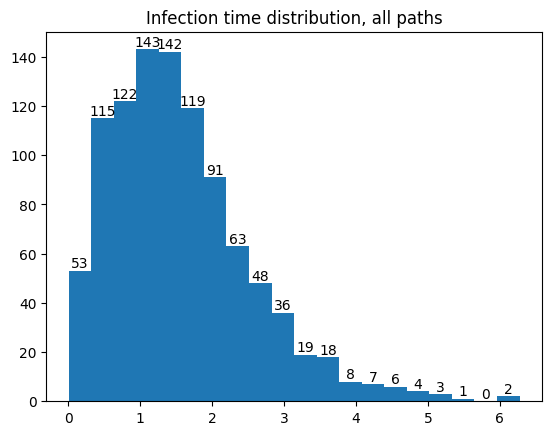

In [23]:
Figures.time_distribution(g._path_times)

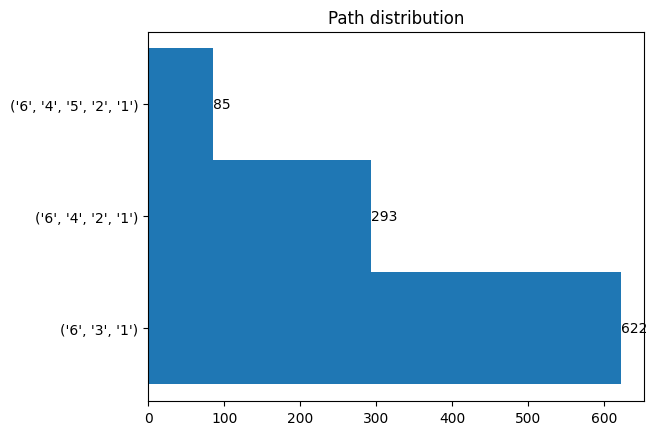

In [24]:
Figures.path_distribution(g._path_counts)

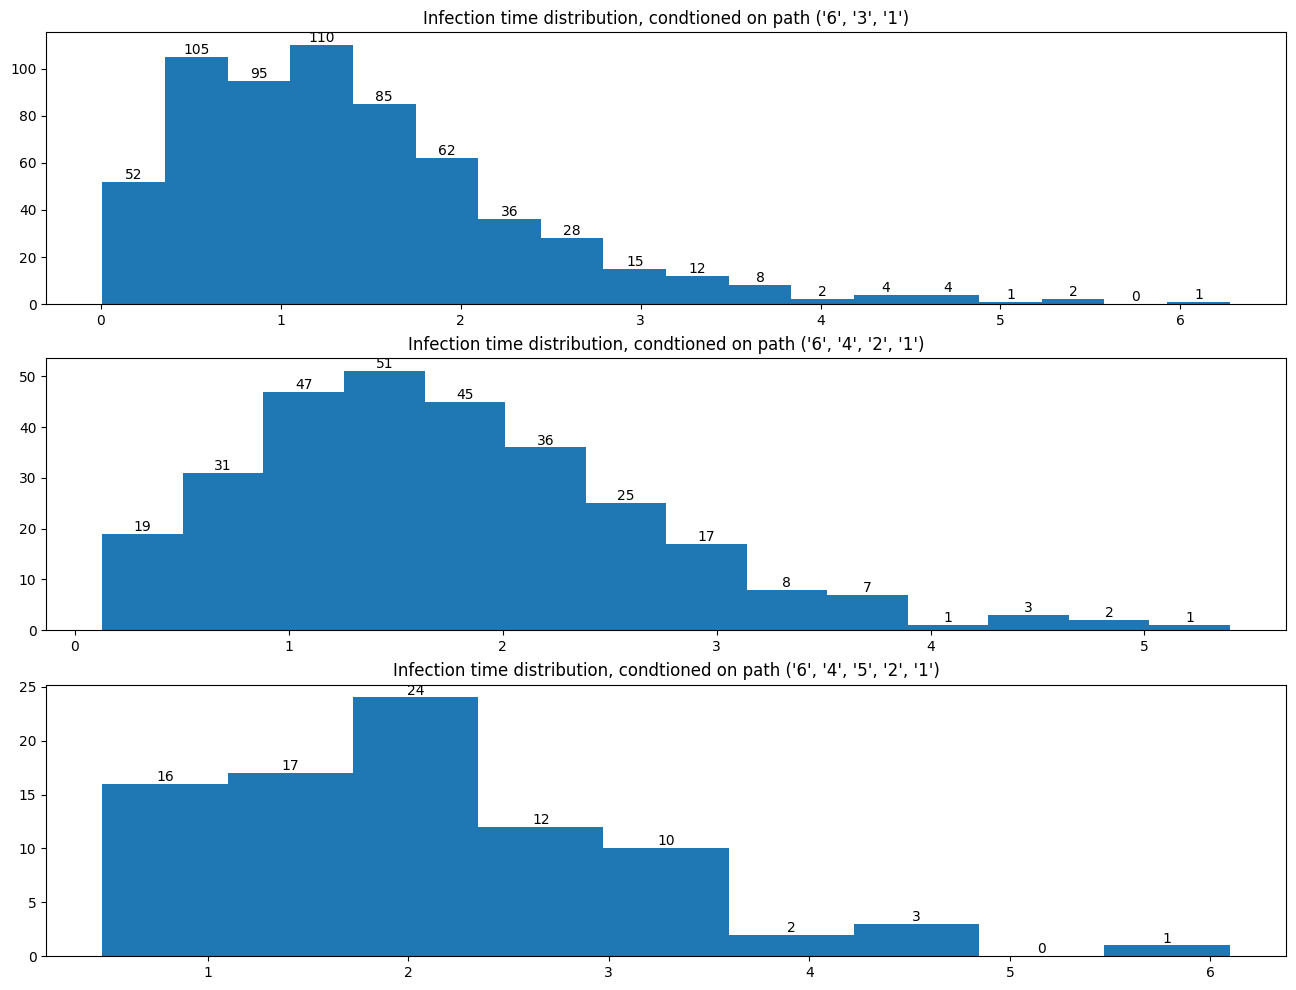

In [25]:
Figures.time_per_path(g._path_times)

# ER

In [26]:
h = Graph.erdos_renyi(7, 0.6, force_connection=True)
h.edge_set

{('0',
  '2',
  <tree_source_localization.EdgeDistribution.EdgeDistribution at 0x7f9f870210f0>),
 ('0',
  '3',
  <tree_source_localization.EdgeDistribution.EdgeDistribution at 0x7f9f87021be0>),
 ('0',
  '4',
  <tree_source_localization.EdgeDistribution.EdgeDistribution at 0x7f9f870217f0>),
 ('0',
  '5',
  <tree_source_localization.EdgeDistribution.EdgeDistribution at 0x7f9f87021940>),
 ('1',
  '2',
  <tree_source_localization.EdgeDistribution.EdgeDistribution at 0x7f9f87021080>),
 ('1',
  '5',
  <tree_source_localization.EdgeDistribution.EdgeDistribution at 0x7f9f87021b00>),
 ('1',
  '6',
  <tree_source_localization.EdgeDistribution.EdgeDistribution at 0x7f9f87021b70>),
 ('2',
  '5',
  <tree_source_localization.EdgeDistribution.EdgeDistribution at 0x7f9f87021ef0>),
 ('2',
  '6',
  <tree_source_localization.EdgeDistribution.EdgeDistribution at 0x7f9f87021f60>),
 ('3',
  '5',
  <tree_source_localization.EdgeDistribution.EdgeDistribution at 0x7f9f87021fd0>),
 ('3',
  '6',
  <tree_source_l

In [27]:
h._adjency_matrix

,2,3,4,5,6,0,1
0,,,,,,,
0,<tree_...,<tree_...,<tree_...,<tree_...,inf,inf,inf
1,<tree_...,inf,inf,<tree_...,<tree_...,inf,inf
2,inf,inf,inf,<tree_...,<tree_...,<tree_...,<tree_...
3,inf,inf,inf,<tree_...,<tree_...,<tree_...,inf
4,inf,inf,inf,inf,<tree_...,<tree_...,inf
5,<tree_...,<tree_...,inf,inf,<tree_...,<tree_...,<tree_...
6,<tree_...,<tree_...,<tree_...,<tree_...,inf,inf,<tree_...


In [28]:
h.reset_data()
h.reset_simulation()
h.simulate_gossip_rv('1','3')

0.5081768311150294

In [29]:
h.reset_data()
h.reset_simulation()
h.simulation_trial('0', '6', iters=100)
h.construct_path('0','6')

['6', '0']

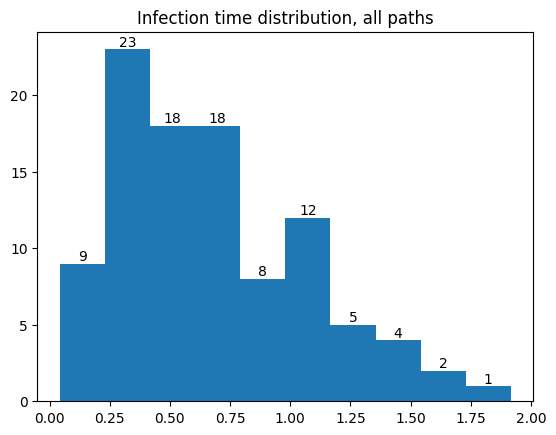

In [30]:
Figures.time_distribution(h._path_times)

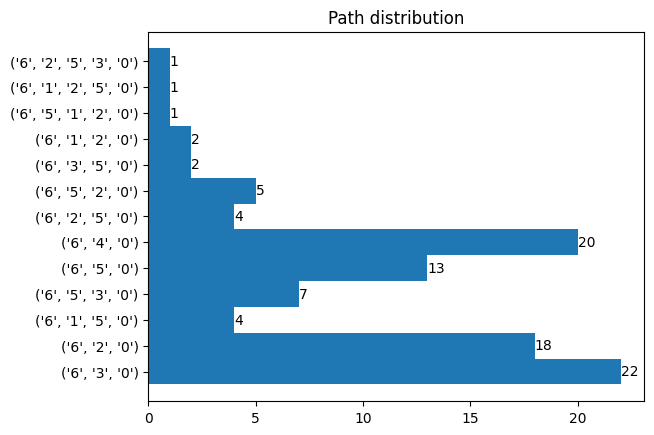

In [31]:
Figures.path_distribution(h._path_counts)

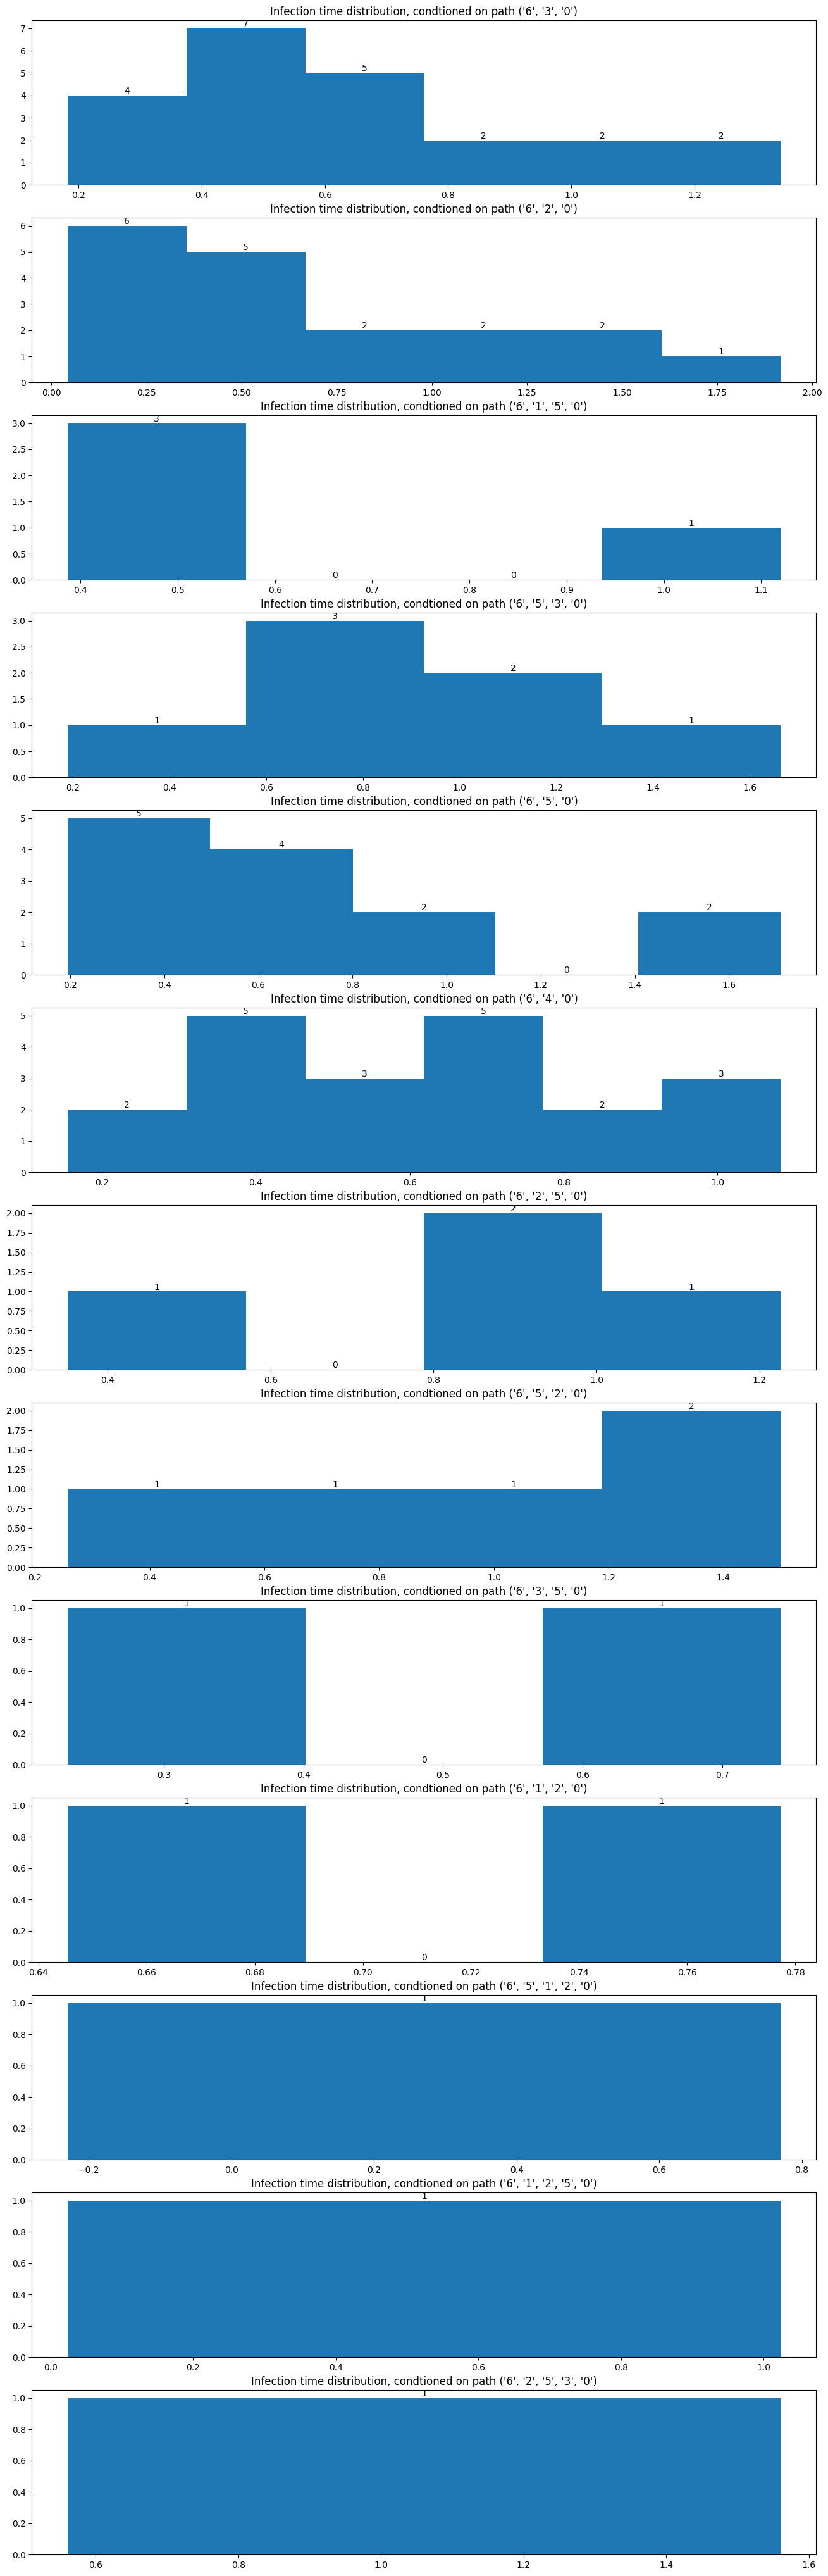

In [32]:
Figures.time_per_path(h._path_times)

In [33]:
data = Graph.erdos_renyi_simulation_trial(4, 0.7, '0', '3', iters=10)

In [34]:
data

(defaultdict(<function infection_propagation.Graph.erdos_renyi_simulation_trial.<locals>.<lambda>()>,
             {('3', '0'): 7, ('3', '1', '0'): 3}),
 defaultdict(list,
             {('3', '0'): [0.8238244056304602,
               2.4169529075047143,
               0.7213380452387931,
               0.3841131741557306,
               0.24383635000150997,
               0.40599301367150853,
               0.4497893873195105],
              ('3', '1', '0'): [0.3999435573022251,
               3.9959245991808583,
               2.188892498796272]}))

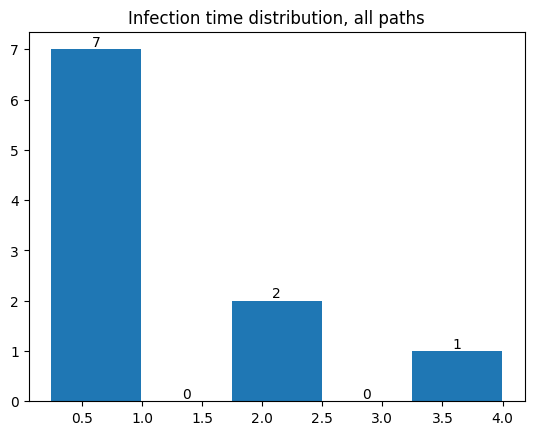

In [35]:
Figures.time_distribution(data[1])

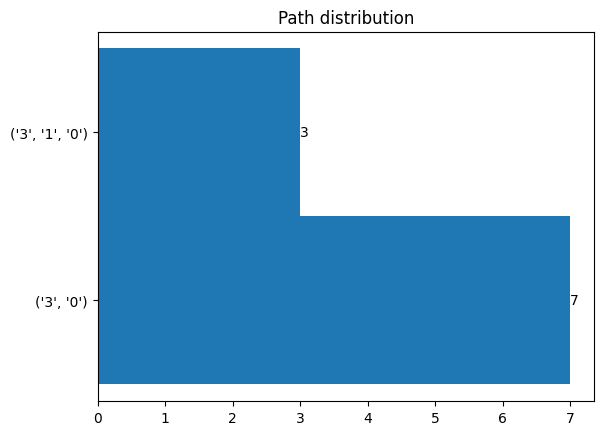

In [36]:
Figures.path_distribution(data[0])

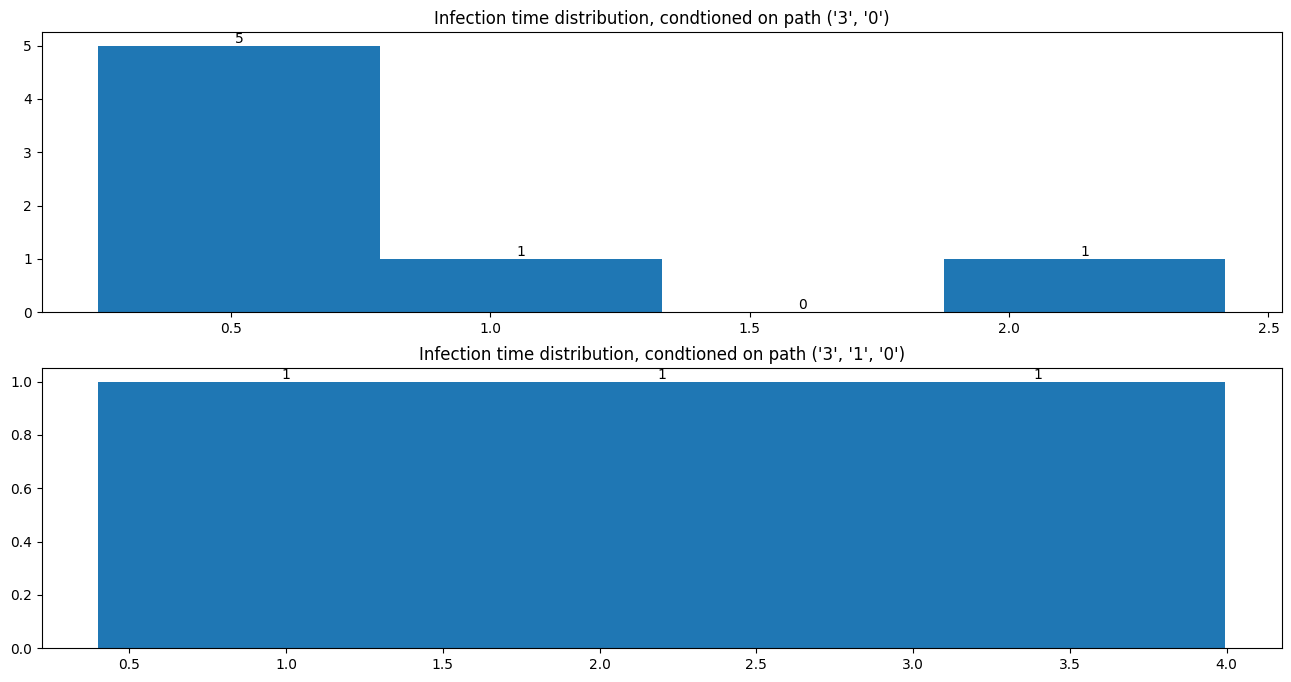

In [37]:
Figures.time_per_path(data[1])

# is_connected benchmarking

In [38]:
# Connection function
c1_times = []
c2_times = []
for _ in range(10):
    h = Graph.erdos_renyi(100, 0.9)
    t0 = time.time()
    _ = h.is_connected()
    t1 = time.time()
    c1_times.append(t1-t0)
    t0 = time.time()
    _ = h.is_connected_laplacian()
    t1 = time.time()
    c2_times.append(t1-t0)

c1_times = np.array(c1_times)
c2_times = np.array(c2_times)
print(f"First connection function avg time: {c1_times.mean()}")
print(f"Second connection function avg time: {c2_times.mean()}")

First connection function avg time: 0.001786351203918457
Second connection function avg time: 0.033264660835266115


It appears calculating laplacian is ~10x shower than just using bfs, speculate this is due to using pandas as the data structure and possible data copying. Consistently ~10x slower